# Competition Workbench

Clean experimental notebook derived from `baseline.ipynb`.

Scope:
- Preserve the baseline data flow
- Keep the same model and feature set
- Add clear sections for future experiments


## 1. Setup


In [41]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

SEED = 2025
FOLD_SEED = 42
PATH = Path.cwd()
print('Working directory:', PATH)


Working directory: /Users/koushiksadhukhan/Desktop/Sem 4/GCI 2026/competition


## 2. Load Data


In [42]:
train = pd.read_csv(PATH / 'train.csv')
test = pd.read_csv(PATH / 'test.csv')
sample_sub = pd.read_csv(PATH / 'sample_submission.csv')

print(f'train: {train.shape}, test: {test.shape}, sample_sub: {sample_sub.shape}')


train: (2781, 16), test: (696, 15), sample_sub: (696, 2)


## 3. Quick Checks


In [43]:
print('Train shape:', train.shape)
print('Test shape:', test.shape)

train.head()

print('\nTrain info:')
train.info()

print('\nTrain missing values:')
print(train.isnull().sum())

print('\nTest missing values:')
print(test.isnull().sum())


Train shape: (2781, 16)
Test shape: (696, 15)

Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2781 non-null   int64  
 1   Year              2781 non-null   int64  
 2   Age               2346 non-null   float64
 3   School            2781 non-null   object 
 4   Height            2781 non-null   float64
 5   Weight            2781 non-null   float64
 6   Sprint_40yd       2636 non-null   float64
 7   Vertical_Jump     2227 non-null   float64
 8   Bench_Press_Reps  2060 non-null   float64
 9   Broad_Jump        2200 non-null   float64
 10  Agility_3cone     1811 non-null   float64
 11  Shuttle           1869 non-null   float64
 12  Player_Type       2781 non-null   object 
 13  Position_Type     2781 non-null   object 
 14  Position          2781 non-null   object 
 15  Drafted           2781 non-nul

## 4. Baseline EDA


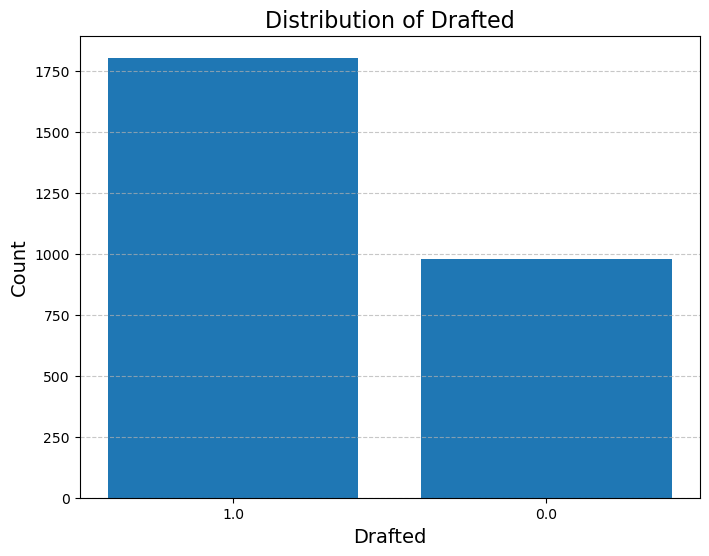

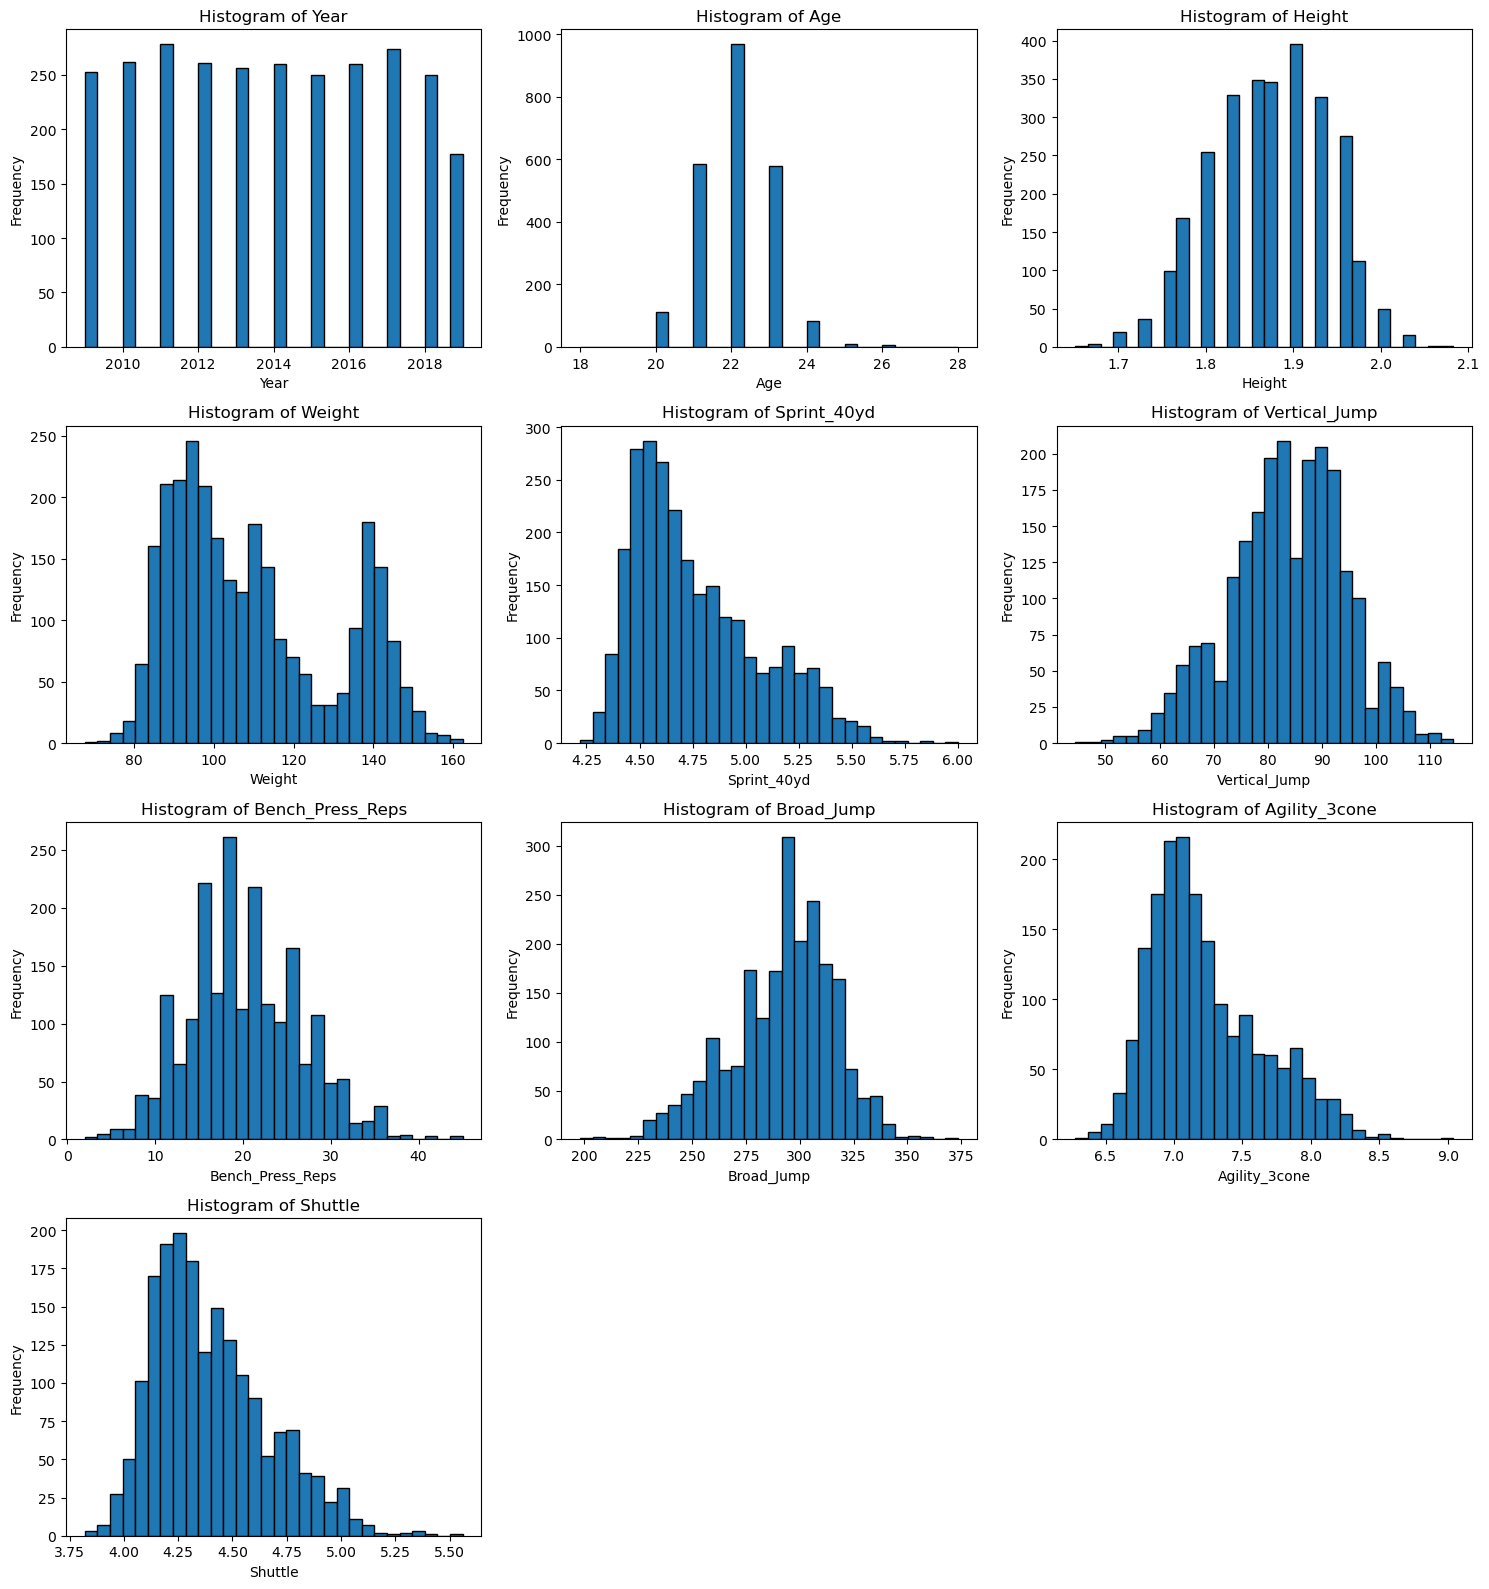

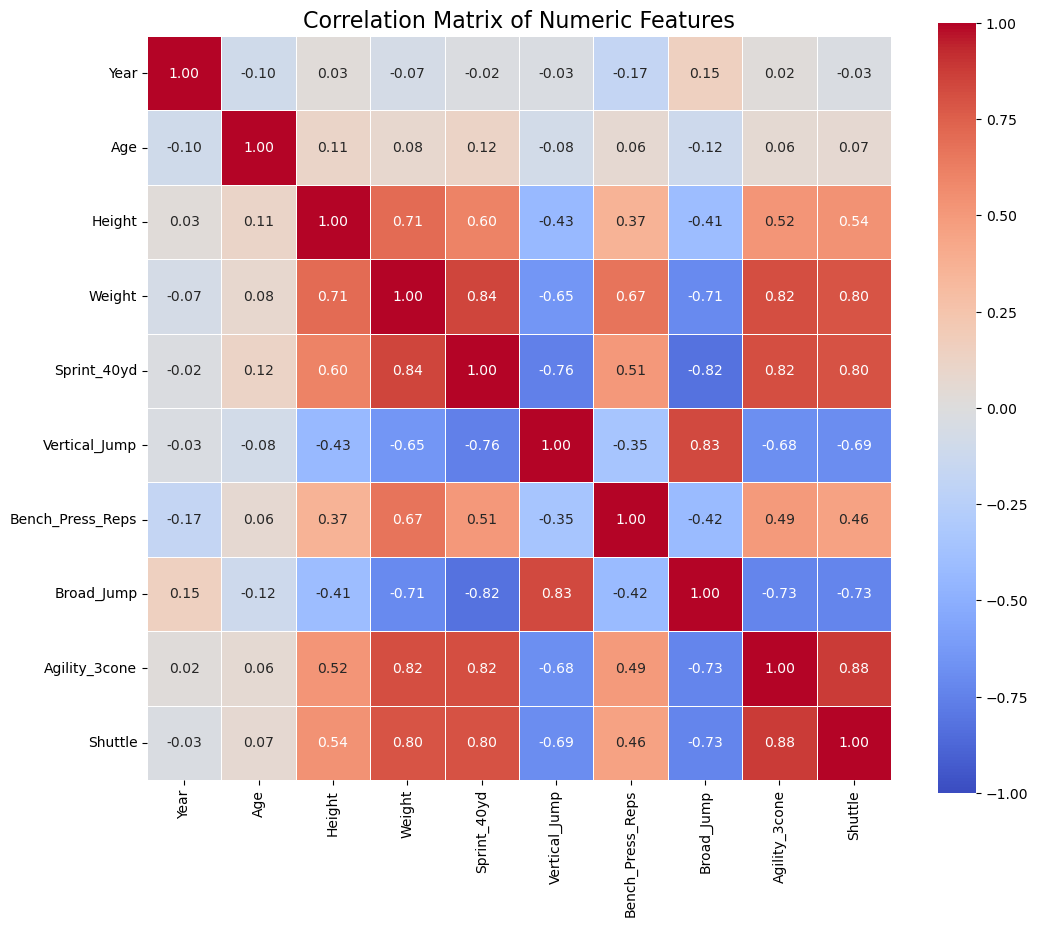

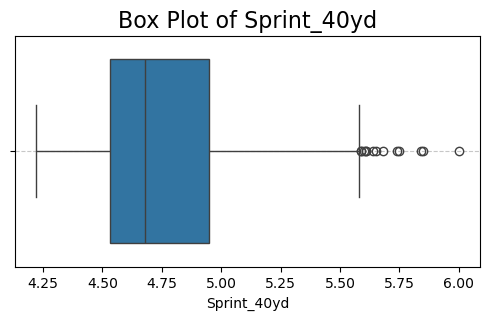

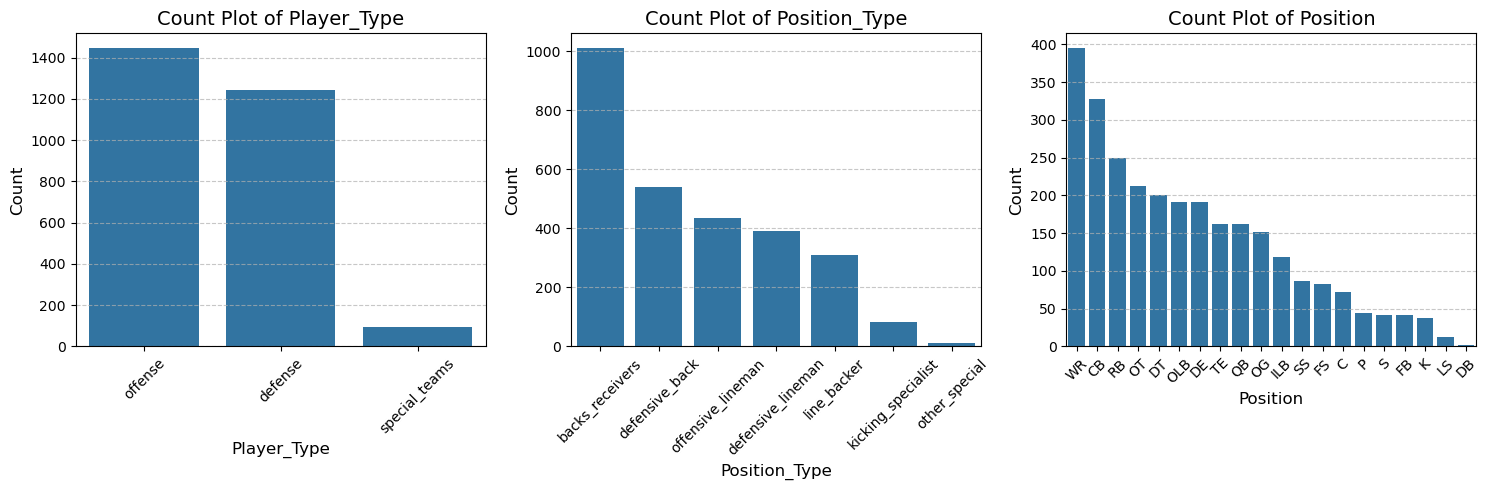

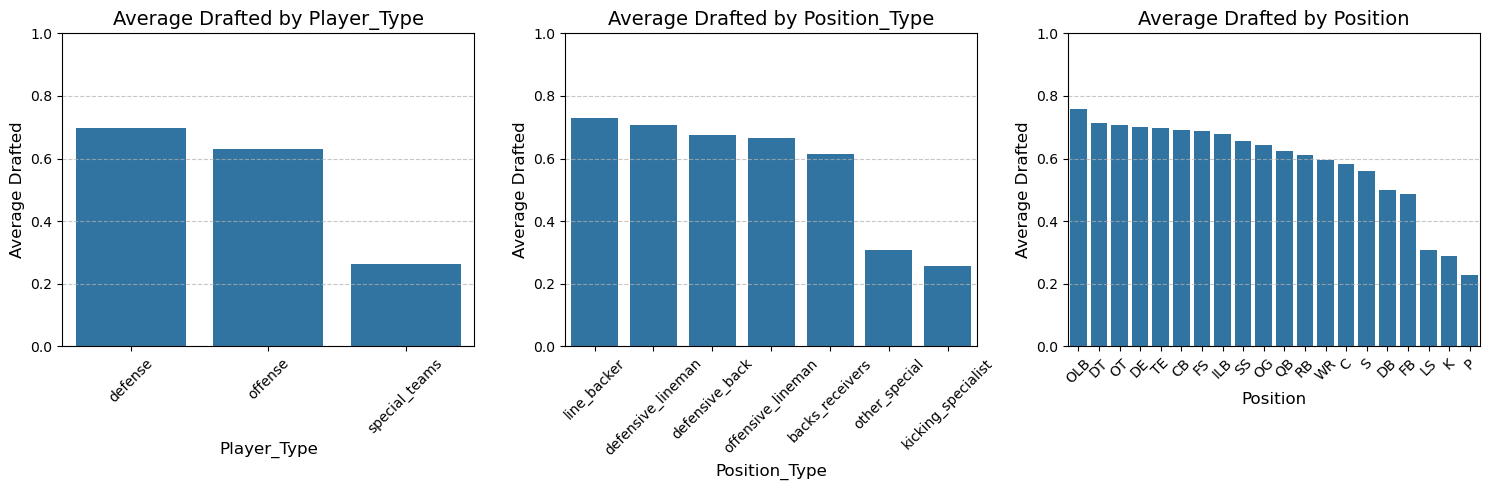

In [44]:
def plot_target_distribution(df):
    drafted_counts = df['Drafted'].value_counts()
    plt.figure(figsize=(8, 6))
    plt.bar(drafted_counts.index.astype(str), drafted_counts.values)
    plt.title('Distribution of Drafted', fontsize=16)
    plt.xlabel('Drafted', fontsize=14)
    plt.ylabel('Count', fontsize=14)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


def plot_numeric_histograms(df):
    numeric_cols = df.select_dtypes(include=['number']).columns.drop(['Id', 'Drafted'])
    num_cols = len(numeric_cols)
    cols = 3
    rows = (num_cols + cols - 1) // cols

    plt.figure(figsize=(5 * cols, 4 * rows))
    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(rows, cols, i)
        plt.hist(df[col].dropna(), bins=30, edgecolor='black')
        plt.title(f'Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


def plot_numeric_correlation(df):
    numeric_cols = df.select_dtypes(include=['number']).drop(['Id', 'Drafted'], axis=1)
    corr_matrix = numeric_cols.corr()

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        vmin=-1, vmax=1,
        square=True,
        linewidths=0.5
    )
    plt.title('Correlation Matrix of Numeric Features', fontsize=16)
    plt.show()


def plot_sprint_boxplot(df):
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df['Sprint_40yd'])
    plt.title('Box Plot of Sprint_40yd', fontsize=16)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


def plot_categorical_counts(df):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.drop('School')
    num_cols = len(categorical_cols)
    fig, axes = plt.subplots(1, num_cols, figsize=(5 * num_cols, 5))

    if num_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(categorical_cols):
        sns.countplot(x=col, data=df, order=df[col].value_counts().index, ax=axes[i])
        axes[i].set_title(f'Count Plot of {col}', fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('Count', fontsize=12)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


def plot_categorical_target_means(df):
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.drop('School')
    num_cols = len(categorical_cols)
    fig, axes = plt.subplots(1, num_cols, figsize=(5 * num_cols, 5))

    if num_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(categorical_cols):
        mean_values = df.groupby(col)['Drafted'].mean().sort_values(ascending=False)
        sns.barplot(x=mean_values.index, y=mean_values.values, ax=axes[i])
        axes[i].set_title(f'Average Drafted by {col}', fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('Average Drafted', fontsize=12)
        axes[i].set_ylim(0, 1)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()


plot_target_distribution(train)
plot_numeric_histograms(train)
plot_numeric_correlation(train)
plot_sprint_boxplot(train)
plot_categorical_counts(train)
plot_categorical_target_means(train)


## 5. Preprocessing


In [45]:
def prepare_data(train_df, test_df):
    train_processed = train_df.copy()
    test_processed = test_df.copy()

    school_counts = train_processed['School'].value_counts()
    train_processed['School_count'] = train_processed['School'].map(school_counts).fillna(0)
    test_processed['School_count'] = test_processed['School'].map(school_counts).fillna(0)

    cols_to_fill = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                    'Broad_Jump', 'Agility_3cone', 'Shuttle']

    for col in cols_to_fill:
        train_processed[f'{col}_missing'] = train_processed[col].isna().astype(int)
        test_processed[f'{col}_missing'] = test_processed[col].isna().astype(int)

    train_processed['BMI'] = train_processed['Weight'] / (train_processed['Height'] ** 2)
    test_processed['BMI'] = test_processed['Weight'] / (test_processed['Height'] ** 2)
    train_processed['SPEED_SCORE'] = (train_processed['Weight'] * 200) / (train_processed['Sprint_40yd'] ** 4)
    test_processed['SPEED_SCORE'] = (test_processed['Weight'] * 200) / (test_processed['Sprint_40yd'] ** 4)

    vj_mean = train_processed['Vertical_Jump'].mean()
    vj_std = train_processed['Vertical_Jump'].std()
    bj_mean = train_processed['Broad_Jump'].mean()
    bj_std = train_processed['Broad_Jump'].std()
    train_processed['EXPLOSIVENESS'] = 0.5 * (
        (train_processed['Vertical_Jump'] - vj_mean) / vj_std
        + (train_processed['Broad_Jump'] - bj_mean) / bj_std
    )
    test_processed['EXPLOSIVENESS'] = 0.5 * (
        (test_processed['Vertical_Jump'] - vj_mean) / vj_std
        + (test_processed['Broad_Jump'] - bj_mean) / bj_std
    )

    train_processed = train_processed.drop(columns=['Id', 'School'])
    test_processed = test_processed.drop(columns=['Id', 'School'])

    for col in cols_to_fill:
        mean_value = train_processed[col].mean()
        train_processed[col] = train_processed[col].fillna(mean_value)
        test_processed[col] = test_processed[col].fillna(mean_value)

    for col in ['SPEED_SCORE', 'EXPLOSIVENESS']:
        train_processed[col] = train_processed[col].replace([np.inf, -np.inf], np.nan)
        test_processed[col] = test_processed[col].replace([np.inf, -np.inf], np.nan)
        mean_value = train_processed[col].mean()
        train_processed[col] = train_processed[col].fillna(mean_value)
        test_processed[col] = test_processed[col].fillna(mean_value)

    label_encoders = {}
    for col in ['Player_Type', 'Position_Type', 'Position']:
        label_encoders[col] = LabelEncoder()
        train_processed[col] = label_encoders[col].fit_transform(train_processed[col].astype(str))
        test_processed[col] = label_encoders[col].transform(test_processed[col].astype(str))

    return train_processed, test_processed, label_encoders


train_processed, test_processed, label_encoders = prepare_data(train, test)
X = train_processed.drop(columns=['Drafted'])
y = train_processed['Drafted']

print('Prepared feature matrix:', X.shape)
print('Prepared target vector:', y.shape)
print('Prepared test matrix:', test_processed.shape)


Prepared feature matrix: (2781, 24)
Prepared target vector: (2781,)
Prepared test matrix: (696, 24)


## 6. Ensemble Evaluation

In [46]:
CURRENT_FEATURE_SET = 'Workbench + School Count Encoding + Missing Indicators + BMI + SPEED_SCORE + EXPLOSIVENESS'
CURRENT_PREPROCESSING = 'Mean Imputation + Label Encoding + School Count Encoding + Missing Indicators + BMI + SPEED_SCORE + EXPLOSIVENESS'

RANDOM_FOREST_PARAMS = {
    'n_estimators': 100,
    'max_depth': 5,
    'random_state': SEED,
}

TUNED_CATBOOST_PARAMS = {
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'iterations': 400,
    'learning_rate': 0.03654113675342291,
    'depth': 4,
    'l2_leaf_reg': 5.946538137175175,
    'min_data_in_leaf': 11,
    'random_strength': 1.0175536836933734,
    'bagging_temperature': 2.0747131960172585,
    'border_count': 137,
    'random_seed': SEED,
    'verbose': False,
    'allow_writing_files': False,
}


def make_random_forest():
    return RandomForestClassifier(**RANDOM_FOREST_PARAMS)


def make_tuned_catboost():
    return CatBoostClassifier(**TUNED_CATBOOST_PARAMS)


def evaluate_model_cv(model_name, model_factory, X, y, X_test, fit_kwargs_factory=None):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=FOLD_SEED)
    oof_predictions = np.zeros(len(X))
    fold_test_predictions = []
    fold_aucs = []

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = model_factory()
        fit_kwargs = fit_kwargs_factory(X_valid, y_valid) if fit_kwargs_factory else {}
        model.fit(X_train, y_train, **fit_kwargs)

        valid_pred = model.predict_proba(X_valid)[:, 1]
        test_pred = model.predict_proba(X_test)[:, 1]

        oof_predictions[valid_idx] = valid_pred
        fold_test_predictions.append(test_pred)
        fold_aucs.append(roc_auc_score(y_valid, valid_pred))

    return {
        'model_name': model_name,
        'oof_auc': roc_auc_score(y, oof_predictions),
        'mean_fold_auc': float(np.mean(fold_aucs)),
        'fold_aucs': fold_aucs,
        'oof_predictions': oof_predictions,
        'test_predictions': np.mean(fold_test_predictions, axis=0),
    }


def catboost_fit_kwargs(X_valid, y_valid):
    return {
        'eval_set': (X_valid, y_valid),
        'use_best_model': True,
        'early_stopping_rounds': 50,
    }


def percentile_rank(values):
    return pd.Series(values).rank(method='average', pct=True).to_numpy()


random_forest_result = evaluate_model_cv(
    'RandomForest',
    make_random_forest,
    X,
    y,
    test_processed,
)

tuned_catboost_result = evaluate_model_cv(
    'Tuned CatBoost',
    make_tuned_catboost,
    X,
    y,
    test_processed,
    fit_kwargs_factory=catboost_fit_kwargs,
)

ensemble_candidates = []

mean_average_oof = (
    random_forest_result['oof_predictions'] + tuned_catboost_result['oof_predictions']
) / 2
mean_average_test = (
    random_forest_result['test_predictions'] + tuned_catboost_result['test_predictions']
) / 2
ensemble_candidates.append({
    'name': 'Mean Average',
    'oof_auc': roc_auc_score(y, mean_average_oof),
    'oof_predictions': mean_average_oof,
    'test_predictions': mean_average_test,
})

rank_average_oof = (
    percentile_rank(random_forest_result['oof_predictions'])
    + percentile_rank(tuned_catboost_result['oof_predictions'])
) / 2
rank_average_test = (
    percentile_rank(random_forest_result['test_predictions'])
    + percentile_rank(tuned_catboost_result['test_predictions'])
) / 2
ensemble_candidates.append({
    'name': 'Rank Average',
    'oof_auc': roc_auc_score(y, rank_average_oof),
    'oof_predictions': rank_average_oof,
    'test_predictions': rank_average_test,
})

best_ensemble_result = max(ensemble_candidates, key=lambda item: item['oof_auc'])
improvement = best_ensemble_result['oof_auc'] - tuned_catboost_result['oof_auc']
use_ensemble = improvement > 1e-6

selected_result = best_ensemble_result if use_ensemble else tuned_catboost_result
selected_label = best_ensemble_result['name'] if use_ensemble else tuned_catboost_result['model_name']
test_pred_proba_mean = selected_result['test_predictions']

interpretation_model = make_tuned_catboost()
interpretation_model.fit(X, y)
importance_reference_label = 'Tuned CatBoost'

ensemble_summary = {
    'feature_set': CURRENT_FEATURE_SET,
    'preprocessing': CURRENT_PREPROCESSING,
    'validated_models': [
        random_forest_result,
        tuned_catboost_result,
    ],
    'ensemble_candidates': ensemble_candidates,
    'best_single_model_name': tuned_catboost_result['model_name'],
    'best_single_model_oof_auc': tuned_catboost_result['oof_auc'],
    'best_ensemble_name': best_ensemble_result['name'],
    'best_ensemble_oof_auc': best_ensemble_result['oof_auc'],
    'improvement': improvement,
    'use_ensemble': use_ensemble,
    'selected_label': selected_label,
    'importance_reference_label': importance_reference_label,
}

print('Validated model OOF ROC-AUC scores:')
for result in ensemble_summary['validated_models']:
    print(f"  {result['model_name']}: {result['oof_auc']:.6f}")
print('Ensemble OOF ROC-AUC scores:')
for result in ensemble_summary['ensemble_candidates']:
    print(f"  {result['name']}: {result['oof_auc']:.6f}")
print('Improvement over tuned CatBoost:', f"{improvement:.6f}")
print('Selected pipeline:', selected_label)
if use_ensemble:
    print('Promoted ensemble method:', best_ensemble_result['name'])
else:
    print('Retained tuned CatBoost as the default pipeline.')


Validated model OOF ROC-AUC scores:
  RandomForest: 0.826997
  Tuned CatBoost: 0.840338
Ensemble OOF ROC-AUC scores:
  Mean Average: 0.836973
  Rank Average: 0.835746
Improvement over tuned CatBoost: -0.003365
Selected pipeline: Tuned CatBoost
Retained tuned CatBoost as the default pipeline.


## 7. Model Interpretation


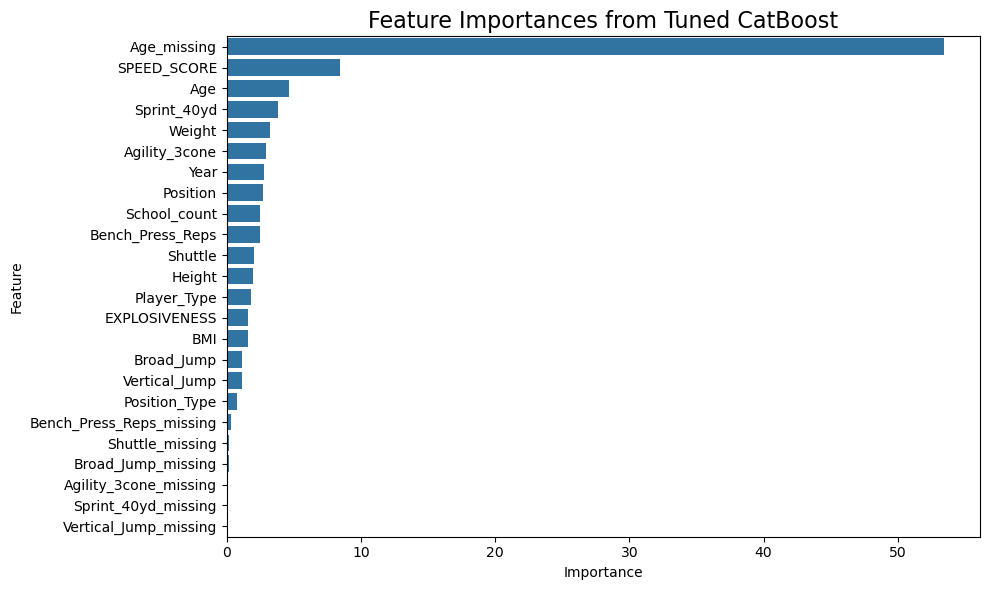

In [47]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': interpretation_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title(
    f'Feature Importances from {ensemble_summary["importance_reference_label"]}',
    fontsize=16,
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## 8. Reporting And Submission


In [48]:
timestamp = pd.Timestamp.now(tz='Asia/Kolkata').isoformat()

submission = pd.read_csv(PATH / 'sample_submission.csv')
submission['Drafted'] = test_pred_proba_mean
submission.to_csv(PATH / 'submission.csv', index=False)

report_lines = [
    '# Ensemble Report',
    '',
    f'- Timestamp: `{timestamp}`',
    f"- Feature set: `{ensemble_summary['feature_set']}`",
    f"- Preprocessing: `{ensemble_summary['preprocessing']}`",
    '- Step: `12`',
    '- Methods: `Mean Average, Rank Average`',
    "- Top validated models: `RandomForest, Tuned CatBoost`",
    '',
    '## Validated Models',
    '',
]

for result in ensemble_summary['validated_models']:
    report_lines.extend([
        f"### {result['model_name']}",
        '',
        f"- OOF ROC-AUC: `{result['oof_auc']:.6f}`",
        f"- Mean Fold ROC-AUC: `{result['mean_fold_auc']:.6f}`",
        f"- Fold Scores: `{', '.join(f'{score:.6f}' for score in result['fold_aucs'])}`",
        '',
    ])

report_lines.extend([
    '## Ensemble Results',
    '',
])

for result in ensemble_summary['ensemble_candidates']:
    report_lines.extend([
        f"### {result['name']}",
        '',
        f"- OOF ROC-AUC: `{result['oof_auc']:.6f}`",
        '',
    ])

report_lines.extend([
    '## Decision',
    '',
])

if ensemble_summary['use_ensemble']:
    report_lines.extend([
        f"- Best single model: `{ensemble_summary['best_single_model_name']}` at `{ensemble_summary['best_single_model_oof_auc']:.6f}` OOF ROC-AUC.",
        f"- Best ensemble: `{ensemble_summary['best_ensemble_name']}` at `{ensemble_summary['best_ensemble_oof_auc']:.6f}` OOF ROC-AUC.",
        f"- Improvement vs best single model: `{ensemble_summary['improvement']:.6f}`.",
        f"- Promoted `{ensemble_summary['best_ensemble_name']}` as the default pipeline in `competition_workbench.ipynb`.",
        '- Regenerated `submission.csv` with ensemble predictions.',
        '- Appended a new experiment row to `experiments.csv`.',
    ])
else:
    report_lines.extend([
        f"- Best single model: `{ensemble_summary['best_single_model_name']}` at `{ensemble_summary['best_single_model_oof_auc']:.6f}` OOF ROC-AUC.",
        f"- Best ensemble: `{ensemble_summary['best_ensemble_name']}` at `{ensemble_summary['best_ensemble_oof_auc']:.6f}` OOF ROC-AUC.",
        f"- Delta vs best single model: `{ensemble_summary['improvement']:.6f}`.",
        '- No ensemble improved on tuned CatBoost validation performance.',
        '- Retained tuned CatBoost as the default pipeline in `competition_workbench.ipynb`.',
        '- Left `experiments.csv` unchanged.',
    ])

(PATH / 'ensemble_report.md').write_text('\n'.join(report_lines) + '\n', encoding='utf-8')

if ensemble_summary['use_ensemble']:
    experiments = pd.read_csv(PATH / 'experiments.csv')
    existing_step12 = experiments['notes'].fillna('').str.contains('Step 12 ensemble', regex=False)

    if not existing_step12.any():
        next_id = f"EXP{len(experiments) + 1:03d}"
        experiments.loc[len(experiments)] = {
            'experiment_id': next_id,
            'timestamp': timestamp,
            'feature_set': CURRENT_FEATURE_SET,
            'preprocessing': CURRENT_PREPROCESSING,
            'model': 'Ensemble',
            'cv_auc': round(ensemble_summary['best_ensemble_oof_auc'], 6),
            'public_score': '',
            'notes': f"Step 12 ensemble via {ensemble_summary['best_ensemble_name']}; promoted improved ensemble and regenerated submission.csv locally",
        }
        experiments.to_csv(PATH / 'experiments.csv', index=False)

print('Saved submission.csv')
print('Saved ensemble_report.md')
if ensemble_summary['use_ensemble']:
    print('Updated experiments.csv')
else:
    print('experiments.csv unchanged')
submission.head()


Saved submission.csv
Saved ensemble_report.md
experiments.csv unchanged


,Id,Drafted
0,2781,0.563228
1,2782,0.806546
2,2783,0.920191
3,2784,0.905589
4,2785,0.844447


## 9. Experiment Sections


### Experiment Log Template

Use this notebook to compare future experiments without changing the baseline pipeline.

- Experiment ID:
- Feature set:
- Preprocessing:
- Model:
- CV AUC:
- Public score:
- Notes:
